In [1]:
import os
import baltic as bt
import pandas as pd
from datetime import datetime, timedelta, date
from collections import OrderedDict
import numpy as np
from collections import defaultdict, Counter
from plotnine import *
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import plotly.express as px

ModuleNotFoundError: No module named 'plotly'

In [2]:
def decimal_year_to_datetime(decimal_year):
    year = int(decimal_year)
    remainder = decimal_year - year

    start = datetime(year, 1, 1)
    end = datetime(year + 1, 1, 1)

    return start + timedelta(seconds=remainder * (end - start).total_seconds())

In [3]:
def load_tree(nexusPath):
    mytree = bt.loadNexus(nexusPath, tip_regex='\|([0-9]{4}\-[0-9]{2}\-[0-9]{2})', absoluteTime=True, verbose=False) # your tip regex might have to change or you could convert you tree into a newick by deleting everything before the tree string lol
    return(mytree)

In [5]:
# Load tree

# nexusPath = "../H5N5-mini-project/SERAPHIM/A6_concat_genome_skyride_DTA-contphyl_2026-01-06_MCC_region-renamed.tree"
# nexusPath = "./SERAPHIM/A6_concat-genome_traits_2026-03-01_MCC_renamed.tree"
# nexusPath = "./SERAPHIM/seraphim_2026-03-10/A6_concat-genome_traits_2026-03-10_MCC.tree"
nexusPath = "./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_MCC.tree"

In [6]:
# Set trait name

traitName = "region"

In [7]:
tree = load_tree(nexusPath)
tree.treeStats()


Tree height: 5.417775
Tree length: 112.448746
strictly bifurcating tree

Numbers of objects in tree: 723 (361 nodes and 362 leaves)



In [8]:
# tree = bt.loadNexus("./SERAPHIM/A6_concat-genome_traits_2026-03-10_MCC.tree", absoluteTime=False, verbose=False)

In [9]:
# print(dir(tree.Objects[4]))
# print(tree.Objects[4].traits)

In [10]:
print(tree.Objects[0].absoluteTime)
# print(2025.8575342465754 - tree.Objects[4].traits["height"] + tree.Objects[4].height)
# print(tree.Objects[4].absoluteTime - tree.Objects[4].length)
print(f"absoluteTime {tree.Objects[0].absoluteTime} = MRSD - tree height + node height {2026.0520547945205 - tree.treeHeight + tree.Objects[4].height}")
print(tree.Objects[0].length)
print(tree.Objects[0].traits["length"])
print(f"height {tree.Objects[0].height} is calculated by length + parent node height {tree.Objects[4].length + tree.Objects[4].parent.height}")

2020.6342799752788
absoluteTime 2020.6342799752788 = MRSD - tree height + node height 2021.081035472743
0.0
0.0
height 0.0 is calculated by length + parent node height 0.4467554974643


In [11]:
# Record the number of states for this trait

unique_states = set()
for node in tree.Objects:
    trait_val = node.traits.get(traitName, None)
    if trait_val:
        unique_states.add(trait_val)
print(f"Unique trait states found: {unique_states}")

Unique trait states found: {'north-canada', 'east-canada', 'europe', 'asia', 'northwest-us', 'northeast-us'}


In [12]:
continent_dict = {"north-canada":"north-america",
                  "northeast-us":"north-america",
                  "northwest-us":"north-america",
                  "asia":"asia",
                  "east-canada":"north-america",
                  "europe":"europe",
                  "ancestor":"ancestor"
                 }

# continent_dict = {"north-canada":"north-america",
#                   "new-england":"north-america",
#                   "pacific-northwest":"north-america",
#                   "asia":"asia",
#                   "east-canada":"north-america",
#                   "europe":"europe",
#                   "ancestor":"ancestor"
#                  }

In [44]:
def extract_subtrees(tree, traitName, dictionary):
    
    # tree_strings = defaultdict(list)
    subtype_trees = defaultdict(list)
    region_transitions = Counter()
    continent_transitions = Counter()

    for t in tree.Objects:  # Iterate over branches
        k = t  # branch
        kp = t.parent  # branch's parent

        # Get current node's and its parent's trait states
        kloc = k.traits.get(traitName, 'ancestor')
        kploc = kp.traits.get(traitName, 'ancestor')
        kc = kloc  # Current branch trait value
        kpc = kploc  # Parent branch trait value

        # # Debug: print current and parent trait states
        # print(f"Node: {k} - Trait: {kc} | Parent: {kp} - Trait: {kpc}")
        # # Node: <baltic.baltic.node object at 0x110ae8850> - Trait: europe | Parent: <baltic.baltic.node object at 0x1326a9ad0> - Trait: ancestor

        # I only want to expand subtrees by introductions into North America
        kcont = dictionary[k.traits.get(traitName, 'ancestor')] # Current branch continent
        kpcont = dictionary[kp.traits.get(traitName, 'ancestor')] # Parent branch continent
        # print(f"Node: {k} - Trait: {kcont} | Parent: {kp} - Trait: {kpcont}")
        
        # Count transitions
        if kpc != kc:
            region_transitions[(kpc, kc)] += 1
            # print(f"Transition detected: {kpc} -> {kc}")

        if kpcont != kcont:
            continent_transitions[(kpc, kc)] += 1

        # If contienets do not match, extract subtree
        if kcont != kpcont:
            # traverse_condition = lambda w: w.traits.get(traitName, 'ancestor') == kc
            traverse_condition = lambda w: dictionary[w.traits.get(traitName, 'ancestor')] == kcont
            subtree = tree.subtree(k, traverse_condition=traverse_condition)
            
            if subtree:
                # print(f"Subtree extracted for transition: {kpc} -> {kc}")
                subtree.traverse_tree()  
                subtree.sortBranches()
                # tree_strings[kc].append(subtree.toString())
                subtype_trees[kcont].append((kpcont, subtree))
            else:
                print(f"Subtree extraction failed for {kpcont} -> {kcont}")

    # # Debug: Print final structures
    # print(f"Tree Strings: {dict(tree_strings)}")
    print(f"Subtype Trees: {dict(subtype_trees)}")
    # print(f"Transitions: {dict(transitions)}")

    return subtype_trees, dict(region_transitions), dict(continent_transitions)

In [45]:
#execute subtrees function
subtype_trees, region_transitions, continent_transitions = extract_subtrees(tree, traitName, continent_dict)

# Print subtype_trees to verify its content
print(f"transitions: {region_transitions}")
print(f"subtrees: {continent_transitions}")

Subtype Trees: {'europe': [('ancestor', <baltic.baltic.tree object at 0x3192f5fd0>), ('north-america', <baltic.baltic.tree object at 0x3061a2d90>), ('north-america', <baltic.baltic.tree object at 0x319632b10>), ('north-america', <baltic.baltic.tree object at 0x319a6dc50>), ('north-america', <baltic.baltic.tree object at 0x3195b6210>)], 'north-america': [('europe', <baltic.baltic.tree object at 0x3192b6e90>), ('europe', <baltic.baltic.tree object at 0x319b35450>), ('europe', <baltic.baltic.tree object at 0x31910b050>), ('europe', <baltic.baltic.tree object at 0x3197719d0>), ('europe', <baltic.baltic.tree object at 0x319425310>), ('europe', <baltic.baltic.tree object at 0x31943e7d0>), ('europe', <baltic.baltic.tree object at 0x319ad6d50>), ('europe', <baltic.baltic.tree object at 0x3198b08d0>), ('europe', <baltic.baltic.tree object at 0x31ba779d0>)], 'asia': [('europe', <baltic.baltic.tree object at 0x16e6b3250>), ('europe', <baltic.baltic.tree object at 0x30664aed0>)]}
transitions: {('a

In [28]:
for k, v in subtype_trees.items():
    # print(v) # v is a list of sets of things
    for i in v:
        origin = i[0]
        if "ancestor" in origin:
            print(dir(i[1].root))
            i[1].root.traits = {}
            # i[1].root.traits["height"] = 5
            print(i[1].root.traits)
            print(i[1].root.parent)
            print(len(i[1].root.leaves))
        else:
            print(i[1].root.parent)

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', 'absoluteTime', 'branchType', 'childHeight', 'children', 'height', 'index', 'is_leaf', 'is_leaflike', 'is_node', 'leaves', 'length', 'parent', 'traits', 'x', 'y', 'yRange']
{}
None
150
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None


In [15]:
# Plot the number of transitions from one continent to another

transition_start_list = []
transition_end_list = []
counts_list = []

# Loop through the transitions dictionary
for (from_state, to_state), count in region_transitions.items():
    transition_start_list.append(from_state)
    transition_end_list.append(to_state)
    counts_list.append(count)  # Get the corresponding count

# Create a DataFrame
transitions_df = pd.DataFrame({'Start': transition_start_list, "End": transition_end_list, 'Count': counts_list})

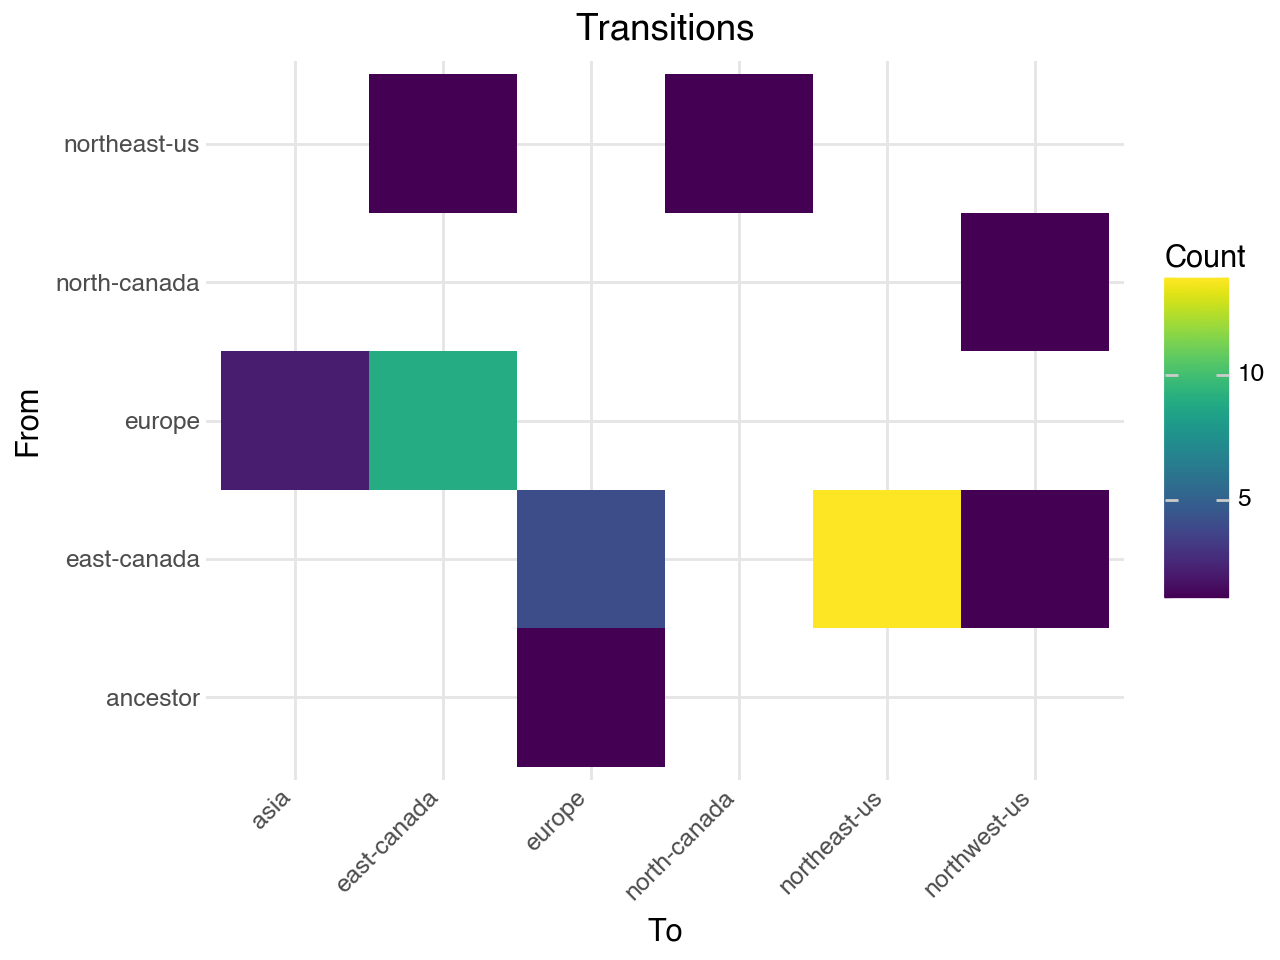

          Start           End  Count
0      ancestor        europe      1
1        europe   east-canada      9
2   east-canada  northeast-us     14
3        europe          asia      2
4  northeast-us  north-canada      1
5  north-canada  northwest-us      1
6   east-canada  northwest-us      1
7   east-canada        europe      4
8  northeast-us   east-canada      1


In [16]:
transitions_plot = (
    ggplot(transitions_df, aes(x = "End", y = "Start", fill = "Count")) 
    + geom_tile() 
    + labs(title = "Transitions", x = "To", y = "From")
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

transitions_plot.show()
print(transitions_df)

In [17]:
def subtree_to_dataframe_with_origin(subtype_trees, traitName, most_recent_date):
    # List to hold all subtree data
    all_subtree_data = []

    # Iterate over each subtype and its associated subtrees
    for subtype, subtree_list in subtype_trees.items():
        for i, (origin, subtree) in enumerate(subtree_list):
            # Extract the origin date, assuming it's the root's absoluteTime minus its length
            if subtree.root.absoluteTime == None: # ancestral root
                origin_date = most_recent_date - subtree.treeHeight
                print(origin_date)
            else:
                origin_date = subtree.root.absoluteTime - subtree.root.length
            # origin_date = subtree.root.date
            
            # Iterate through nodes in the subtree
            for node in subtree.Objects:
                # Collect relevant information from each node
                node_info = {
                    'branchType': node.branchType,  # 'leaf' or 'internal'
                    'date': node.absoluteTime,
                    # 'date': node.date,
                    'length': node.length,
                    'origin': origin,  # Include the origin trait
                    'origin_date': origin_date,  # Add the origin date here
                    'subtree_name': f"{subtype}_{i}",  # Unique name for the subtree
                    'traits': node.traits  # This is a dictionary; we can expand it later if needed
                }
                
                # Expand the traits dictionary into individual columns
                for trait, value in node.traits.items():
                    node_info[trait] = value  # Each trait becomes its own column

                # Add this node's information to the list
                all_subtree_data.append(node_info)
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_subtree_data)
    
    # Drop the node_attrs column if it exists (assuming it may not be needed)
    if 'node_attrs' in df.columns:
        df.drop(columns=['node_attrs', 'traits'], inplace=True)

    return df

In [18]:
# execute function and store in combined df
# combined_df = subtree_to_dataframe_with_origin(subtype_trees, traitName, 2025.8575342465754)
# combined_df.to_csv(f"output/subtree_dataframe1_{treename}_{todays_date}.csv", index=False)
combined_df = subtree_to_dataframe_with_origin(subtype_trees, traitName, 2026.0520547945205)

combined_df.head(5)  # Display the first 10 rows of the DataFrame

2020.6342799752788


,branchType,date,length,origin,origin_date,subtree_name,traits,location2_median,location1_median,posterior,...,region.rate_95%_HPD,location.rate_range,location1_80%HPD_3,location1_80%HPD_2,location2_80%HPD_2,location2_80%HPD_3,location1_80%HPD_4,location2_80%HPD_4,location1_80%HPD_5,location2_80%HPD_5
0,node,NaN,0.000000,ancestor,2020.63428,europe_0,{},NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,2020.634280,0.000000,ancestor,2020.63428,europe_0,"{'location2_median': 74.55022770243563, 'locat...",74.550228,66.921230,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,2021.428776,0.769406,ancestor,2020.63428,europe_0,"{'host.rate_median': 0.2261525599555195, 'loca...",91.924191,66.799966,0.922309,...,"[0.03934033265531206, 0.19458123142043524]","[0.00035273506040613123, 10.256850736530088]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,leaf,2021.852055,0.703291,ancestor,2020.63428,europe_0,"{'host.rate_median': 0.22772608212439774, 'loc...",93.849107,66.750802,NaN,...,"[0.04215209773831166, 0.20192484585370987]","[0.009051388601871041, 11.46222272369493]","[66.75152975, 66.75163465, 66.75166686, 66.751...","[66.75826923, 66.75822071, 66.75809911, 66.757...","[93.84808097, 93.84804836, 93.84797268, 93.847...","[93.85512258, 93.85497243, 93.85492046, 93.854...",NaN,NaN,NaN,NaN
4,leaf,2021.739726,0.579376,ancestor,2020.63428,europe_0,"{'host.rate_median': 0.22548330273485873, 'loc...",93.852975,66.757717,NaN,...,"[0.0399509395226881, 0.2082078699860635]","[0.0020225232988545327, 12.205527543253131]","[66.75759972, 66.75741564, 66.75727469, 66.757...","[66.75744814, 66.75741564, 66.75731553, 66.757...","[93.85322686, 93.85322461, 93.85321691, 93.853...","[93.8530416, 93.85304001, 93.85303768, 93.8530...",NaN,NaN,NaN,NaN


In [19]:
def make_subtree_df(combined_df):
    # Function to convert decimal year to date
    def decimal_year_to_date(decimal_year):
        year = int(decimal_year)
        decimal_part = decimal_year - year
        days_in_year = 365.25  # Average including leap years
        day_of_year = int(decimal_part * days_in_year)
        return datetime(year, 1, 1) + timedelta(days=day_of_year)

    # Make a new DataFrame that pulls out only leaf nodes and groups by subtree_name
    tip_counts = combined_df[combined_df['branchType'] == 'leaf'].groupby('subtree_name').size().reset_index(name='leaf_count')

    # Make separate sub DataFrame that pulls out the origin date, origin, and trait of tips of each subtree
    origin_info = combined_df[['subtree_name', 'origin_date', 'origin', 'region']].drop_duplicates()

    # Merge origin sub DataFrame into tip_counts
    tip_counts = pd.merge(tip_counts, origin_info, on='subtree_name')

    # Filter to only include leaf nodes
    leaf_nodes = combined_df[combined_df['branchType'] == 'leaf']

    # Group by 'subtree_name' and get the max absoluteTime for each subtree
    last_tip_dates = leaf_nodes.groupby('subtree_name')['date'].max().reset_index()

    # Rename the column to 'last_tip_date'
    last_tip_dates.rename(columns={'date': 'last_tip_date'}, inplace=True)

    # Merge more recent tip dates into the tip_counts sub DataFrame
    tip_counts = tip_counts.merge(last_tip_dates, on='subtree_name', how='left')

    # Convert origin_date and last_tip_date to datetime
    tip_counts['origin_date'] = tip_counts['origin_date'].apply(decimal_year_to_date)
    tip_counts['last_tip_date'] = tip_counts['last_tip_date'].apply(decimal_year_to_date)

    # Now calculate and add persistence times in days
    tip_counts['subtree_duration_days'] = (tip_counts['last_tip_date'] - tip_counts['origin_date']).dt.days

    # Round the persistence times
    tip_counts['subtree_duration_days'] = tip_counts['subtree_duration_days'].round(1)

    # Return the final DataFrame
    return tip_counts

In [20]:
# execute function of making subtree dataframe for subtree analyses
tip_counts = make_subtree_df(combined_df)
tip_counts.head(5)
# tip_counts.to_csv(f"output/subtree_dataframe2_{treename}_{todays_date}.csv", index=False)

,subtree_name,leaf_count,origin_date,origin,region,last_tip_date,subtree_duration_days
0,asia_0,2,2024-10-12,europe,europe,2026-01-12,457
1,asia_0,2,2024-10-12,europe,asia,2026-01-12,457
2,asia_1,32,2022-05-07,europe,europe,2024-04-29,723
3,asia_1,32,2022-05-07,europe,asia,2024-04-29,723
4,europe_0,150,2020-08-19,ancestor,NaN,2026-01-20,1980


In [21]:
# def plot_tree(subtype_trees, traitName, tree, 
#               tip_size=15, fig_size=(10, 10), legend_loc='lower left'):
   
#     # Define color scheme for traits
#     colors = {"europe":"#ffaaaa",
#               "east-canada":"#95b8d1",
#               "new-england":"#f7df7d",
#               "north-canada":"#ba9cc9",
#               "pacific-northwest":"#94bf73",
#               "asia":"#b09a6e"
#          }

#     host_colors = {"seab":"#6aa1f4", 
#                "bdpr": "#f69ba6", 
#                "gds": "#6a994e", 
#                "mammal": "#a874d2", 
#                "scav": "#923e4d", 
#                "grdbd": "#e9c46a"
#               }
    
#     # Define the subtypes, since they're different from the colors
#     subtypes = ["europe", "asia", "north-america"]

#     # Color function based on traits
#     # c_func = lambda k: colors.get(k.traits[traitName], 'grey')
#     c_func = lambda k: host_colors.get(k.traits["host"], 'grey')
    
#     # Initialize figure and cumulative y offset
#     fig = plt.figure(figsize=fig_size, facecolor='w')
#     gs = gridspec.GridSpec(1, 1, wspace=0.0)
#     ax = plt.subplot(gs[0], facecolor='w')
#     cumulative_y = 0

#     # Iterate over each trait and its subtrees
#     for subtype in subtypes:
#         for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
#             origin, loc_tree = tr
#             y_attr = lambda k: k.y + cumulative_y  # Update y-attribute with cumulative offset

#             # Plot the subtree branches and tips
#             loc_tree.plotTree(ax, x_attr=lambda k: k.absoluteTime, y_attr=y_attr, colour=c_func)
#             loc_tree.plotPoints(ax, x_attr=lambda k: k.absoluteTime, y_attr=y_attr, size=tip_size, colour=c_func, zorder=100)
            
#             # Origin point for each subtree
#             oriC = 'dimgrey' if origin == 'ancestor' else c_func(loc_tree.root.parent)
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriY = loc_tree.root.y + cumulative_y
#             ax.scatter(oriX, oriY, 50, facecolor=oriC, edgecolor='w', lw=1, zorder=200)  # Origin circle

#             # Add absoluteTime text at the subtree origin
#             origin_time = loc_tree.root.absoluteTime - loc_tree.root.length
#             origin_min_95hpd = 2025.8575342465754 - loc_tree.root.traits["height_95%_HPD"][0]
#             origin_max_95hpd = 2025.8575342465754 - loc_tree.root.traits["height_95%_HPD"][1]
#             # origin_time = loc_tree.root.absoluteTime
#             if len(loc_tree.Objects) > 5: # If the subtree is larger than 1 or 2 leaves, label beneath the origin
#                 ax.text(oriX + 0.04, oriY - 5, f"{origin_time:.2f}", ha='right', va='top', fontsize=8, color= "#000000", zorder=300)
#                 #ax.text(oriX - 0.1, oriY - 11, f"[{origin_min_95hpd:.2f},", ha='right', va='top', fontsize=8, color= "#000000", zorder=300)
#                 #ax.text(oriX - 0.05, oriY - 11, f"{origin_max_95hpd:.2f}]", ha='left', va='top', fontsize=8, color= "#000000", zorder=300)
#             else: # if the subtree is smaller, label behind the origin
#                 ax.text(oriX - 0.03, oriY + 3.5, f"{origin_time:.2f}", ha='right', va='top', fontsize=8, color= "#000000", zorder=300)
#                 #ax.text(oriX, oriY, f"[{origin_min_95hpd:.2f},", ha='right', va='top', fontsize=8, color= "#000000", zorder=300)
#                 #ax.text(oriX, oriY, f"{origin_max_95hpd:.2f}]", ha='left', va='top', fontsize=8, color= "#000000", zorder=300)

#             cumulative_y += loc_tree.ySpan + 5  # Update cumulative y for next subtree

#     # Axis and plot styling
#     ax.xaxis.tick_bottom()
#     ax.yaxis.tick_left()
#     [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
#     ax.tick_params(axis='x', size=0, labelsize=15)
#     ax.tick_params(axis='y', size=0)
#     ax.grid(axis='x', ls='--')
    
    
#     # Set y-axis limits and remove labels
#     ax.set_yticklabels([])
#     ax.set_ylim(-35, cumulative_y + 35)
#     # Determine the min and max dates in the tree
#     min_date = min(node.absoluteTime for node in tree.Objects)
#     max_date = max(node.absoluteTime for node in tree.Objects)

#     # Add in dashed lines at the midpoints as well
#     xticks = ax.get_xticks()
#     midpoints = np.mean([xticks[:-1], xticks[1:]], axis=0)
#     ax.vlines(midpoints, *ax.get_ylim(), linestyles='--', colors='gray', linewidth = 0.8, alpha = 0.4)
    
#     # Set x-axis limits with some padding
#     padding = 0.2  # Adjust padding as desired
#     ax.set_xlim(min_date - padding, max_date + padding)    
#     # Legend setup
#     handles = [
#         plt.Line2D([0], [0], marker='o', color='w', label=label,
#                    markersize=10, markerfacecolor=color)
#         for label, color in colors.items()
#     ]
#     #plt.legend(handles=handles, title='Traits', loc=legend_loc)
    
#     # Adjust layout and show plot
#     plt.gcf().subplots_adjust(right=0.88)
#     # plt.title(treename + "_" + todays_date)
#     output_filename = "./SERAPHIM/output_plots/exploded_A6_concat-genome_region_2026-03-10_MCC.pdf"
#     # plt.savefig(output_filename, format='pdf')
#     # plt.show()


In [22]:
mpl.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})

In [26]:
def plot_tree(subtype_trees, traitName, tree, continent_dict,
              tip_size=15, fig_size=(10, 10), legend_loc='lower left'):
   
    # Define color scheme for traits
    colors = {"europe":"#ffaaaa",
              "east-canada":"#95b8d1",
              "northeast-us":"#f7df7d",
              "north-canada":"#ba9cc9",
              "northwest-us":"#94bf73",
              "asia":"#b09a6e"
             }

    host_colors = {"seab":"#6aa1f4", 
                   "bdpr": "#f69ba6",
                   "gds": "#6a994e",
                   "mammal": "#a874d2",
                   "scav": "#923e4d",
                   "grdbd": "#e9c46a"
                  }

    origin_shape = {"europe":"s","east-canada":"^","northeast-us":"^","north-canada":"^","northwest-us":"^","asia":"v"}
    
    # Define the subtypes, since they're different from the colors
    subtypes = ["europe", "asia", "north-america"]

    # Color function based on traits
    # c_func = lambda k: colors.get(k.traits[traitName], 'grey') # Color for region
    c_func = lambda k: host_colors.get(k.traits["host"], 'grey') # Color for host

    tipSize = 20

    s_func = lambda k: origin_shape.get(k.traits["region"], "o") # set the shape based on the continent, default is circle

    # Initialize figure and cumulative y offset
    fig = plt.figure(figsize=fig_size, facecolor='w')
    gs = gridspec.GridSpec(1, 1, wspace=0.0)
    ax = plt.subplot(gs[0], facecolor='w')

    cumulative_y = 0
    y_func = lambda k: k.y + cumulative_y # Function to update y-attribute with cumulative offset

    most_recent_sampling_date = 2026.0520547945205

    # Iterate over each trait and its subtrees
        
    for subtype in subtypes:
        # for i, (_, tree) in enumerate(subtype_trees[subtype]):
        #     print(f"Tree {i}: {subtype}")
        #     print(tree.root.traits)
        #     print()
        # for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: ((most_recent_sampling_date - (-x[1].root.traits["height"])), len(x[1].Objects)))):
        for t, tr in enumerate(subtype_trees[subtype]):
            origin, loc_tree = tr
            subtree = tr[1]
            
            for k in subtree.Objects: 
                # print(continent_dict[subtree.root.parent.traits["region"]])
                if "ancestor" in origin:
                    x = 0.0
                    y =  y_func(k)
                    s = tipSize
                    xp = 0.0
                else:
                    x = most_recent_sampling_date - k.traits["height"]
                    y =  y_func(k)
                    s = tipSize
                    # if "height" in k.parent.traits: # if the parent has a "height"
                    if k.parent != None:
                        xp = most_recent_sampling_date - k.parent.traits["height"]
                    elif k.parent == None: # If the parent is the root
                        xp = 0.0 # Parent x coordinate is 0
                    
                
                # if x==None: # If no "height", then x = 0
                #     x=0.0

                # if "height" in k.parent.traits: # if the parent has a "height"
                #     xp = most_recent_sampling_date - k.parent.traits["height"]
                # elif xp == None: # If the parent is the root
                #     xp = 0.0 # Parent x coordinate is 0
                # else: 
                #     xp = 0.0 # else, x coordinate is 0?

                if k == subtree.root: # for the origin of each subtree
                    
                    # if k.parent.traits != {}: # If the introduction is not the root of the tree (AKA if it has traits)
                    if k.parent != None:

                        origin_time = most_recent_sampling_date - k.parent.traits["height"]
                        origin_dt = decimal_year_to_datetime(origin_time)
                        formatted = origin_dt.strftime("%b %d %Y") # Change date format
                        
                        origin_min_95hpd = most_recent_sampling_date - k.parent.traits["height_95%_HPD"][1]
                        origin_max_95hpd = most_recent_sampling_date - k.parent.traits["height_95%_HPD"][0]
                        
                        if k.branchType == "leaf": # If the introduction resulted in a single tip
                            ax.scatter(xp,y,s=24,facecolor=c_func(k.parent),edgecolor='none',zorder=11, marker = s_func(k.parent)) # plot circle for origin
                            ax.scatter(xp,y,s=43,facecolor='white',edgecolor='none',zorder=10, marker = s_func(k.parent)) # Plot white circle underneath origin
                            ax.scatter(x,y,s=s,facecolor=c_func(k),edgecolor='none',zorder=11) # plot circle leaf
                            ax.scatter(x,y,s=s+0.8*s,facecolor='k',edgecolor='none',zorder=10) # plot black circle underneath
                            ax.plot([xp,x],[y,y],color=c_func(k),ls='-',zorder=9) # plot the horizontal line from origin to leaf

                            ax.text(xp - 0.03, y + 3.5, f"{formatted} [{origin_min_95hpd:.2f},{origin_max_95hpd:.2f}]", 
                                    ha='right', va='top', fontsize=8, color= "#000000", zorder=300)
                            # ax.text(xp, y, f"[{origin_min_95hpd:.2f},", ha='right', va='top', fontsize=8, color= "#000000", zorder=300)
                            # ax.text(xp, y, f"{origin_max_95hpd:.2f}]", ha='left', va='top', fontsize=8, color= "#000000", zorder=300)
                            
                        else: # If the introduction had multiple tips
                            ax.scatter(xp,y,s=24,facecolor=c_func(k.parent),edgecolor='none',zorder=11, marker = s_func(k.parent)) # plot circle for the origin
                            ax.scatter(xp,y,s=43,facecolor='white',edgecolor='none',zorder=10, marker = s_func(k.parent)) # Plot white circle underneath origin
                            ax.plot([xp,x],[y,y],color=c_func(k),ls='-',zorder=9) # plot the horizontal line from origin to the next node
                            ax.plot([x,x], [y_func(k.children[-1]), y_func(k.children[0])], color = c_func(k), zorder = 9) # plot the vertical line between nodes 

                            ax.text(xp + 0.04, y - 9.5, f"{formatted}", 
                                    ha='center', va='bottom', fontsize=8, color= "#000000", zorder=300)
                            ax.text(xp - 0.05, y - 9.5, f"[{origin_min_95hpd:.2f},", ha='right', va='top', fontsize=8, color= "#000000", zorder=300)
                            ax.text(xp - 0.05, y - 9.5, f"{origin_max_95hpd:.2f}]", ha='left', va='top', fontsize=8, color= "#000000", zorder=300)
                            
                    else: # If the introduction is the root
                        ax.scatter(x,y,s=30,facecolor="dimgrey",edgecolor='none',zorder=10) # plot a grey root
                
                elif k.branchType == "leaf": 
                    c = c_func(k)
            
                    ax.scatter(x,y,s=s,facecolor=c,edgecolor='none',zorder=11) # plot circle for every tip
                    ax.scatter(x,y,s=s+0.8*s,facecolor='k',edgecolor='none',zorder=10) # plot black circle underneath
                    ax.plot([xp,x],[y,y],color=c,ls='-',zorder=9)
                
                elif k.branchType == "node": # this more or less plots branches WITHOUT points for each node
                    n_children = len(k.leaves)

                    # this is the vertical line connecting nodes; 
                    ax.plot([x,x], [y_func(k.children[-1]), y_func(k.children[0])], color = c_func(k), zorder = 9)
                    
                    # this is the horizontal line connecting nodes 
                    ax.plot([xp,x],[y,y],color=c_func(k),ls='-',zorder=9)
                    

            cumulative_y += loc_tree.ySpan + 15 # Update y for the next tree
            
    # Axis and plot styling
    ax.xaxis.tick_bottom()
    ax.yaxis.tick_left()
    [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
    ax.tick_params(axis='x', size=0, labelsize=15)
    ax.tick_params(axis='y', size=0)
    ax.grid(axis='x', ls='--')
    
    
    # Set y-axis limits and remove labels
    ax.set_yticklabels([])
    ax.set_ylim(-35, cumulative_y + 35)
    # Determine the min and max dates in the tree
    min_date = min((most_recent_sampling_date - node.traits["height"]) for node in tree.Objects)
    max_date = max((most_recent_sampling_date - node.traits["height"]) for node in tree.Objects)

    # Add in dashed lines at the midpoints as well
    xticks = ax.get_xticks()
    midpoints = np.mean([xticks[:-1], xticks[1:]], axis=0)
    ax.vlines(midpoints, *ax.get_ylim(), linestyles='--', colors='gray', linewidth = 0.8, alpha = 0.4)
    
    # Set x-axis limits with some padding
    padding = 0.2  # Adjust padding as desired
    ax.set_xlim(min_date - padding, max_date + padding)    
    
    # Legend setup
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', label=label,
                   markersize=10, markerfacecolor=color)
        for label, color in colors.items()
    ]
    # plt.legend(handles=handles, title='Traits', loc=legend_loc)
    
    # Adjust layout and show plot
    plt.gcf().subplots_adjust(right=0.88)
    # plt.title(treename + "_" + todays_date)
    # output_filename = "./SERAPHIM/output_plots/exploded_A6_concat-genome_host_2026-03-10_MCC_NEW.pdf"
    # plt.savefig(output_filename, format='pdf')
    plt.show()

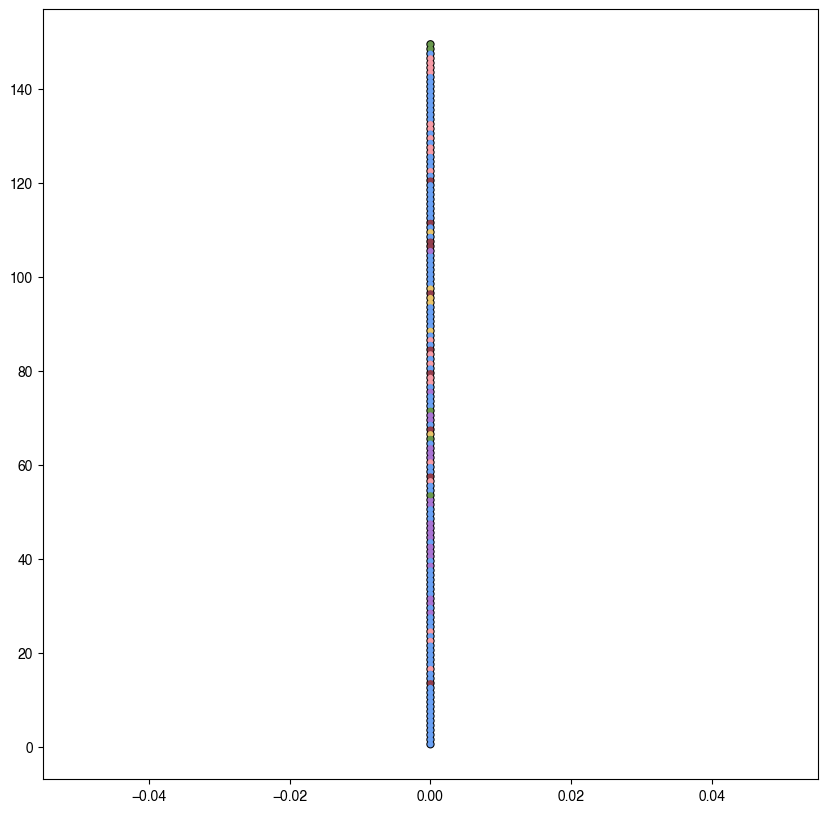

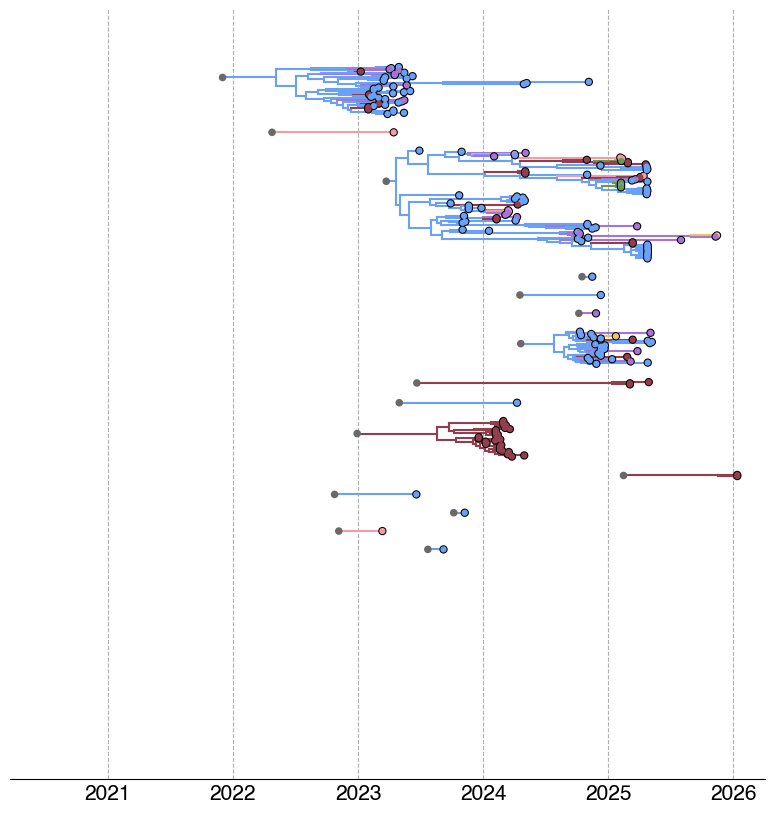

In [27]:
#execute plot trees function
plot_tree(subtype_trees, traitName, tree, continent_dict)

In [44]:
# To measure the cryptic circulation in North America leading up to the human infection

cryptic_circulation_list = []

for obj in tree.Objects:
    if obj.traits["region"] == "northwest-us":
        branchStart = obj.absoluteTime - obj.traits["length"]
        branchStartUpper = obj.absoluteTime - obj.traits["length_95%_HPD"][0]
        branchStartLower = obj.absoluteTime - obj.traits["length_95%_HPD"][1]
        cryptic_circulation_list.append([obj.name, obj.absoluteTime, obj.traits["length"], obj.traits["length_95%_HPD"], obj.traits["length_median"],
                                        branchStart, [branchStartUpper, branchStartLower]])


mini_df = pd.DataFrame(cryptic_circulation_list).rename({0:"name", 1:"tipTime", 2:"branchLength", 
                                                          3:"branchLength_95HPD", 4:"branchLength_median", 
                                                          5:"nodeTime", 6: "nodeStart_95HPD"}, 
                                                         axis = 1)
mini_df.head()

AttributeError: 'node' object has no attribute 'name'

In [340]:
# I want to try Lambo's proportion of edgues thing
# Goal: What dies the transmission within North America look like?
# Question: what proportion of edges are in each region?

In [ ]:
# From here down is crap I was messing with 

In [139]:
label_count = 0

for k in tree.Objects:
    k.label = label_count
    label_count += 1

In [140]:
metadata = []
most_recent_sampling_date = 2025.8575342465754

for obj in tree.Objects:
    children = []

    # if count < 10:
    if obj.is_node():
        children.extend(obj.children) # Use .extend instead of .append, the former makes a flat list while the latter appends a list into the list
        node1 = obj.label
        startYear = most_recent_sampling_date - obj.traits["height"]
        length = obj.traits["length"]
        startOrder = obj.traits["host"]
        startRegion = obj.traits["region"]
        startLat = obj.traits["location1"]
        startLong = obj.traits["location2"]
        
        for child in children:
            node2 = child.label
            endYear = most_recent_sampling_date - child.traits["height"]
            endOrder = child.traits["host"]
            endRegion = child.traits["region"]
            endLat = child.traits["location1"]
            endLong = child.traits["location2"]
            tip = getattr(child, 'name', pd.NA)
            
            metadata.append({
                "node1": node1,
                "node2": node2,
                "length": length,
                "startYear": startYear,
                "endYear": endYear,
                "startLat": startLat,
                "startLon": startLong,
                "endLat": endLat,
                "endLon": endLong,
                "startRegion": startRegion,
                "endRegion": endRegion,
                "startHost": startOrder,
                "endHost": endOrder,
                "tipLabel": tip
                }) 
        # count += 1
                
    else:
        pass

In [141]:
df = pd.DataFrame(metadata)

In [142]:
def get_monthyear(y):
    if 2021.665753 <= y < 2021.747945: 
        return "2021-09"
    elif 2021.747945 <= y < 2021.832877: 
        return "2021-10"
    elif 2021.832877 <= y < 2021.915068: 
        return "2021-11"
    elif 2021.915068 <= y < 2022.000000: 
        return "2021-12"
    elif 2022.000000 <= y < 2022.084932: 
        return "2022-01"
    elif 2022.084932 <= y < 2022.161644:
        return "2022-02"
    elif 2022.161644 <= y < 2022.246575:
        return "2022-03"
    elif 2022.246575 <= y < 2022.328767:
        return "2022-04"
    elif 2022.328767 <= y < 2022.413699:
        return "2022-05"
    elif 2022.413699 <= y < 2022.495890:
        return "2022-06"
    elif 2022.495890 <= y < 2022.580822:
        return "2022-07"
    elif 2022.580822 <= y < 2022.665753:
        return "2022-08"
    elif 2022.665753 <= y < 2022.747945:
        return "2022-09"
    elif 2022.747945 <= y < 2022.832877: 
        return "2022-10"
    elif 2022.832877 <= y < 2022.915068:
        return "2022-11"
    elif 2022.915068 <= y < 2023.000000:
        return "2022-12"
    elif 2023.000000 <= y < 2023.084932:
        return "2023-01"
    elif 2023.084932 <= y < 2023.161644:
        return "2023-02"
    elif 2023.161644 <= y < 2023.246575:
        return "2023-03"
    elif 2023.246575 <= y < 2023.328767:
        return "2023-04"
    elif 2023.328767 <= y < 2023.413699:
        return "2023-05"
    elif 2023.413699 <= y < 2023.495890:
        return "2023-06"
    elif 2023.495890 <= y < 2023.580822:
        return "2023-07"
    elif 2023.580822 <= y < 2023.665753:
        return "2023-08"
    elif 2023.665753 <= y < 2023.747945:
        return "2023-09"
    elif 2023.747945 <= y < 2023.832877:
        return "2023-10"
    elif 2023.832877 <= y < 2023.915068:
        return "2023-11"
    elif 2023.915068 <= y < 2024.000000:
        return "2023-12"
    elif 2024.000000 <= y < 2024.084699:
        return "2024-01"
    elif 2024.084699 <= y < 2024.163934:
        return "2024-02"
    elif 2024.163934 <= y < 2024.248634:
        return "2024-03"
    elif 2024.248634 <= y < 2024.330601:
        return "2024-04"
    elif 2024.330601 <= y < 2024.415301:
        return "2024-05"
    elif 2024.415301 <= y < 2024.497268:
        return "2024-06"
    elif 2024.497268 <= y < 2024.581967:
        return "2024-07"
    elif 2024.581967 <= y < 2024.666667:
        return "2024-08"
    elif 2024.666667 <= y < 2024.748634:
        return "2024-09"
    elif 2024.748634 <= y < 2024.833333:
        return "2024-10"
    elif 2024.833333 <= y < 2024.915301:
        return "2024-11"
    elif 2024.915301 <= y < 2025.00000:
        return "2024-12"
    elif 2025.000000 <= y < 2025.084932:
        return "2025-01"
    elif 2025.084932 <= y < 2025.161644:
        return "2025-02"
    elif 2025.161644 <= y < 2025.246575:
        return "2025-03"
    elif 2025.246575 <= y < 2025.328767:
        return "2025-04"
    elif 2025.328767 <= y < 2025.413699:
        return "2025-05"
    elif 2025.413699 <= y < 2025.495890:
        return "2025-06"
    elif 2025.495890 <= y < 2025.580822:
        return "2025-07"
    elif 2025.580822 <= y < 2025.665753:
        return "2025-08"
    elif 2025.665753 <= y < 2025.747945:
        return "2025-09"
    elif 2025.747945 <= y < 2025.832877:
        return "2025-10"
    elif 2025.832877 <= y < 2025.915068:
        return "2025-11"
    elif 2025.915068 <= y < 2026.00000:
        return "2025-12"
    else:
        return "unknown"

In [143]:
# Assign a month to each row
df["yearmonth"] = df["startYear"].apply(get_monthyear)

# Limit to when start and end region match
df_filtered = df.loc[df["startRegion"] == df["endRegion"]]

In [484]:
rows = []

for month, df in df_filtered.groupby("yearmonth"):
    df_filtered["total_per_month"] = len(df) # Get the total number of branches/edges per month
    for region, df1 in df.groupby("startRegion"):
        df_filtered.loc[df_filtered["startRegion"] == region, "region_per_month"] = len(df1) # for each month and region, get the number of branches/edges
    columns = ["yearmonth", "startRegion", "endRegion", "total_per_month", "region_per_month"]
    rows.append(df_filtered.loc[:, columns])
    
test = pd.concat(rows)
        
# Plot the total number of edges per month, colored by region

# transition_peryr["avg_count"] = transition_peryr.groupby(["tree", "combo"])["count"].transform("mean")

# print(df_filtered["year-month"].value_counts())
print(test)

    yearmonth startRegion endRegion  total_per_month  region_per_month
0     unknown      europe    europe                2               2.0
1     unknown      europe    europe                2               2.0
2     unknown      europe    europe                2               2.0
3     unknown      europe    europe                2               2.0
4     unknown      europe    europe                2               2.0
..        ...         ...       ...              ...               ...
659   2022-05      europe    europe               10              10.0
660   2021-12      europe    europe               10              10.0
661   2021-12      europe    europe               10              10.0
662   2021-10      europe    europe               10              10.0
663   2021-10      europe    europe               10              10.0

[29394 rows x 5 columns]


In [485]:
print(test["total_per_month"].max())

59


In [486]:
def format_date(datestr):
    i = str(datestr)
    date_object = datetime.strptime(i, '%Y-%m')
    return (date_object)

In [487]:
test["yearmonth"] = test["yearmonth"].replace('unknown',np.NaN)

In [488]:
print(test["yearmonth"].value_counts())

yearmonth
2024-08    2714
2024-09    2254
2024-02    1656
2024-01    1426
2024-10    1334
2025-01    1288
2024-07    1150
2023-09    1058
2024-03     920
2024-04     920
2023-12     874
2024-06     828
2022-12     782
2025-03     736
2025-02     736
2023-11     736
2023-10     736
2023-08     690
2025-04     552
2023-01     506
2022-03     460
2024-11     414
2022-09     414
2023-07     414
2023-03     414
2024-12     414
2023-05     368
2022-04     368
2022-08     368
2022-11     368
2023-02     368
2024-05     276
2022-10     276
2022-01     276
2022-05     276
2023-04     230
2021-12     230
2023-06     230
2021-10     184
2022-07     184
2022-06     184
2021-11      92
2025-07      92
2021-09      92
2022-02      46
Name: count, dtype: int64


In [489]:
test["yearmonth"] = test["yearmonth"].dropna(axis = 0, ignore_index = True)

In [490]:
print(test["yearmonth"].value_counts())

yearmonth
2024-08    2622
2024-09    2208
2024-02    1656
2024-01    1380
2024-10    1334
2025-01    1242
2024-07    1058
2024-04    1012
2023-09    1012
2022-12     920
2024-03     920
2023-12     874
2024-06     828
2023-10     736
2025-02     736
2023-11     736
2022-09     690
2023-08     690
2025-03     690
2023-01     598
2023-03     460
2023-02     460
2022-04     460
2023-07     460
2024-11     414
2025-04     414
2022-03     414
2022-11     368
2024-12     368
2023-05     368
2022-08     368
2024-05     276
2021-12     276
2022-06     276
2022-07     276
2022-10     276
2022-01     276
2021-10     230
2022-05     230
2023-06     230
2023-04     184
2021-09     184
2025-07      92
2022-02      46
2021-11      46
Name: count, dtype: int64


In [144]:
print(type(df["startYear"].dtype))

df["datetime"] = df["startYear"].apply(decimal_year_to_datetime)

print(type(df["datetime"].dtype))

<class 'numpy.dtypes.Float64DType'>
<class 'numpy.dtypes.DateTime64DType'>


In [145]:
counts_per_month_rows = []

for group in df.groupby(pd.Grouper(key='datetime', axis=0, freq='ME')):
    month = group[0]
    count_per_month = len(group[1])
    counts_per_month_rows.append({"month":month, "counts": count_per_month})

# print(counts_per_month_rows)

test_df_2 = pd.DataFrame(counts_per_month_rows)

In [146]:
test_df_2 = df.copy()

test_df_2["month_datetime"] = test_df_2["datetime"].dt.to_timestamp("M")

# test_df_2["counts_per_month"] = (test_df_2.groupby("month_datetime")["month_datetime"].transform("size"))
test_df_2["counts_per_monthregion"] = test_df_2.groupby(["month_datetime", "startRegion"]).transform("size")

# for (month, region), df in test_df_2.groupby(["month_datetime", "startRegion"]):
#     test_df_2["counts_per_monthregion"] =len(df)

AttributeError: 'DatetimeProperties' object has no attribute 'to_timestamp'

In [128]:
df_plot = test_df_2.drop_duplicates(["month_datetime", "startRegion"])

In [129]:
print(df_plot)

     node1  node2    length    startYear      endYear   startLat   startLon  \
0        0      1  0.000000  2021.437810  2021.563718  66.492579  65.823770   
2        1      2  0.135517  2021.563718  2021.852055  66.764201  90.586855   
4        4    664  0.157876  2021.613409  2022.512329  65.852801  24.340136   
10       7    659  0.071118  2021.728192  2021.796006  63.942835  11.979315   
12       8      9  0.052506  2021.802202  2021.919109  63.768974  10.065634   
..     ...    ...       ...          ...          ...        ...        ...   
630    618    619  0.090563  2025.006958  2025.101370  41.800015 -69.702346   
632    620    626  0.125819  2025.132777  2025.220312  41.428432 -69.974882   
634    621    625  0.066055  2025.202646  2025.306849  41.285607 -70.191131   
636    622    623  0.059979  2025.262625  2025.306849  41.291032 -70.102060   
648    636    640  0.419062  2024.926654  2025.306849  41.486656 -70.647089   

        endLat     endLon  startRegion    endRegion

In [134]:
df_plot["month_datetime"] = (
    df_plot["month_datetime"]
    .dt.to_timestamp("M")
)

full_index = pd.date_range(start=df_plot["month_datetime"].min(), end=df_plot["month_datetime"].max(), freq='ME')

# 3. Reindex the DataFrame to the full date range and fill missing counts with 0
df_plot_full = df_plot.reindex(full_index, fill_value=0)

AttributeError: 'DatetimeProperties' object has no attribute 'to_timestamp'

In [107]:
print(full_index)

DatetimeIndex([], dtype='datetime64[ns]', freq='ME')


In [103]:
# test["yearmonth_datetime"] = test["yearmonth"].apply(format_date)
# test = test.sort_values("yearmonth")

# test_plt = (
#     ggplot(df)
#     # + geom_line(aes(x = "datetime", y="total_per_month", color = "startRegion"))
#     # + geom_area(aes(x = "datetime", y="total_per_month", fill = "startRegion", group = "startRegion"))
#     + geom_area(aes(x = "datetime", fill = "startRegion", group = "startRegion"), stat = "count")

# )

# test_plt = (
#     ggplot(test_df_2, aes(x = "month_datetime", y = "counts_per_month", fill = "startRegion", group = "startRegion"))
#     + geom_area()
# )

ggplot(
    df_plot,
    aes(
        x="month_datetime",
        y="counts_per_monthregion",
        fill="startRegion"
    )
) + geom_area()

test_plt.show()

TypeError: Bad type of argument 0      2021-06
2      2021-07
4      2021-08
10     2021-09
12     2021-10
        ...   
490    2025-03
634    2025-03
636    2025-04
590    2025-04
314    2025-07
Name: month_datetime, Length: 95, dtype: period[M], expected a dataframe or a mapping.

In [226]:
month_order = ["january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december"]

permonth["month"] = pd.Categorical(permonth["month"], categories=month_order, ordered=True)

In [228]:
# To plot the probability of Markov jumps occuring in each month

permonth_rows = []

mask = ["europe,northamerica","northamerica,europe"]


for (combo, tree), df in treejumps.groupby(["comboContinent","treeNumber"]):
    if combo in mask:
        # df["month"] = df["date"].apply(get_monthyear)
        df["month"] = df["date"].apply(get_seasonyear)
        df["total_trans"] = len(df)
        for month, df2 in df.groupby("month"):
            df.loc[df["month"] == month, "trans_per_month"] = len(df2)
        df["proportion"] = df["trans_per_month"] / df["total_trans"]
        columns = ["treeNumber", "date", "comboContinent", "month", "total_trans", "trans_per_month", "proportion"]
        permonth_rows.append(df.loc[:, columns])
    else:
       pass


permonth = pd.concat(permonth_rows)

print(permonth)

    treeNumber         date       comboContinent   month  total_trans  \
0            1  2023.040812  europe,northamerica  winter           10   
2            1  2023.474435  europe,northamerica  summer           10   
7            1  2022.080602  europe,northamerica  winter           10   
18           1  2023.255891  europe,northamerica  spring           10   
19           1  2024.790202  europe,northamerica  autumn           10   
..         ...          ...                  ...     ...          ...   
19         899  2023.616933  northamerica,europe  summer            4   
9          900  2023.625955  northamerica,europe  summer            4   
19         900  2022.875702  northamerica,europe  autumn            4   
21         900  2023.623217  northamerica,europe  summer            4   
22         900  2023.285337  northamerica,europe  spring            4   

    trans_per_month  proportion  
0               3.0        0.30  
2               1.0        0.10  
7               3.0  